In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import astropy.constants as const
from lmfit.models import gaussian, expgaussian
from scipy.special import erf
from random import choices

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
from matplotlib import cycler
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 80})

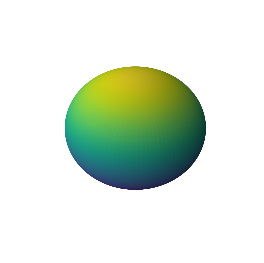

In [26]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from scipy.special import sph_harm

phi = np.linspace(0, np.pi, 100)
theta = np.linspace(0, 2*np.pi, 100)
phi, theta = np.meshgrid(phi, theta)

# The Cartesian coordinates of the unit sphere
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

# Calculate the spherical harmonic Y(l,m) and normalize to [0,1]
fcolors = sph_harm(0, 1, theta, phi).real
fmax, fmin = fcolors.max(), fcolors.min()
fcolors = (fcolors - fmin)/(fmax - fmin)

# Set the aspect ratio to 1 so our sphere looks spherical
fig = plt.figure(figsize=(plt.figaspect(10)))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z,  rstride=1, cstride=1, facecolors=cm.viridis(fcolors))
# Turn off the axis planes
ax.set_axis_off()
plt.show()

In [27]:
from histpy import Histogram

filename = '../../44Ti/data/Ti44_SNsurprise_binned.hdf5'
binned_data = Histogram.open(filename)

In [28]:
binned_data.axes.labels

array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [29]:
binned_data.contents.shape

(2217, 1, 60, 3072)

In [33]:
binned_data.axes['Phi'].edges

<Quantity [  0.,   3.,   6.,   9.,  12.,  15.,  18.,  21.,  24.,  27.,
            30.,  33.,  36.,  39.,  42.,  45.,  48.,  51.,  54.,  57.,
            60.,  63.,  66.,  69.,  72.,  75.,  78.,  81.,  84.,  87.,
            90.,  93.,  96.,  99., 102., 105., 108., 111., 114., 117.,
           120., 123., 126., 129., 132., 135., 138., 141., 144., 147.,
           150., 153., 156., 159., 162., 165., 168., 171., 174., 177.,
           180.] deg>

In [26]:
np.diff(binned_data.axes['Time'].edges[:3])

<Quantity [3599.43843031, 3599.43843031] s>

In [22]:
binned_data.project('Time').to_dense().contents

array([16.,  2., 11., ..., 20.,  2., 23.])

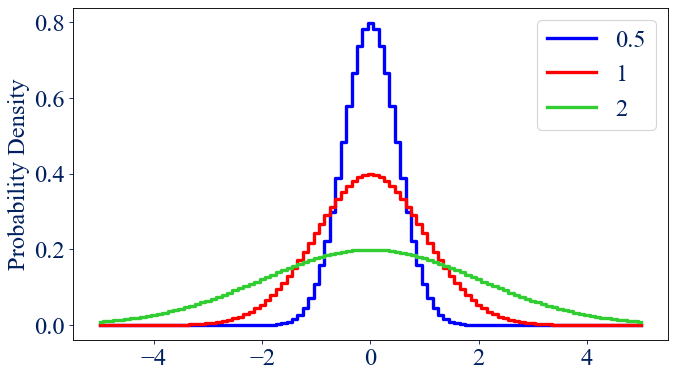

In [16]:
x = np.linspace(-5, 5, 101)

plt.step(x, gaussian(x, sigma=0.5), label='0.5', where='mid')
plt.step(x, gaussian(x, sigma=1), label='1', where='mid')
plt.step(x, gaussian(x, sigma=2), label='2', where='mid')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [2]:
# Copying from lmfit.lineshapes
s2 = np.sqrt(2.0)
tiny = 1.0e-15      # to prevent underflow errors

# See lmfit.lineshapes for additional, well-written function definitions
def expgaussianleft(x, amplitude=1, center=0, sigma=1.0, gamma=1.0):
    '''
    Standard implementation of expgaussian in lmfit.lineshapes is left-skewed

    Here, return a right-skewed, exponentially modified Gaussian.

    For more information, see:
    https://en.wikipedia.org/wiki/Exponentially_modified_Gaussian_distribution
    '''
    gss = -gamma*sigma*sigma
    arg1 = -gamma*(center + gss/2.0 - x)
    arg2 = (center + gss - x)/max(tiny, (s2*sigma))
    return amplitude*(gamma/2) * np.exp(arg1) * (erf(arg2) + 1)

In [238]:
# Test case with Ti-44
mu = 1157
window = 14
simlimit = 1
ADClimit = 1.53

In [239]:
nbins_Ei = int(2*window // simlimit) + 1
nbins_Em = int(2*window // ADClimit) + 1

Ei = np.linspace(mu - window, mu + window, nbins_Ei)
Em = np.linspace(mu - window, mu + window, nbins_Em)
extent = [mu-window, mu+window, mu-window, mu+window]

binwidth_Ei = Ei[1] - Ei[0]     # Binwidths
binwidth_Em = Em[1] - Em[0]

In [240]:
X, Y = np.meshgrid(Ei, Em)

R = np.zeros(X.shape)  # To avoid overflow errors

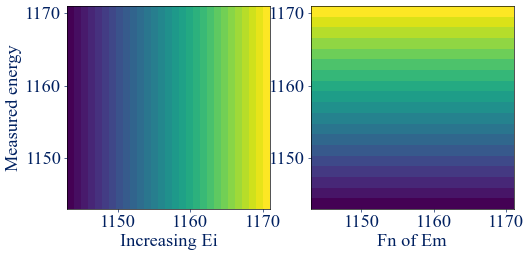

In [241]:
fig, axs = plt.subplots(ncols=2, dpi=60)
axs[0].imshow(X, origin='lower', extent=extent)
axs[0 ].set_xlabel('Increasing Ei')
axs[0 ].set_ylabel('Measured energy')
axs[1].imshow(Y, origin='lower', extent=extent)
axs[1 ].set_xlabel('Fn of Em')
plt.show()

In [242]:
Y.shape, Ei.shape

((19, 29), (29,))

In [243]:
for i in range(nbins_Ei):
    # R[:, i] = expgaussianleft(Y[:,i], amplitude=1, center=Ei[i], sigma=2, gamma=0.3) + tiny    # All y entries for a particular column x'
    R[:, i] = gaussian(Y[:,i], amplitude=1, center=Ei[i], sigma=2) + tiny

Rnoisy = R + np.random.normal(0, np.median(R), R.shape)
Rnorm = np.sum(Rnoisy, axis=1)
R1 = (Rnoisy.T / Rnorm).T            # Scale up R

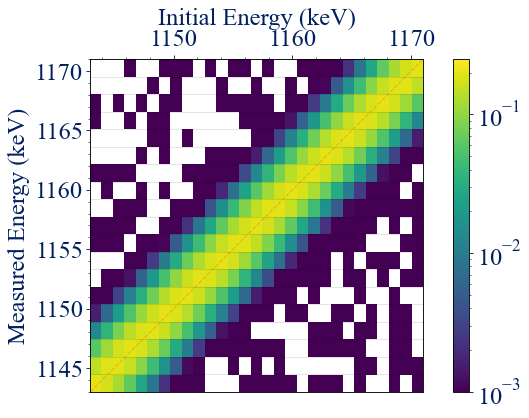

In [244]:
plt.figure()

vmin = 0.001
vmax = 0.25
plt.imshow(Rnoisy, origin='lower',
           norm=LogNorm (vmin=vmin, vmax=vmax),
           aspect=1,
           extent=extent
           )
plt.xlabel('Initial Energy (keV)')
plt.ylabel('Measured Energy (keV)')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top') 
plt.minorticks_on()
plt.plot([Ei.min(), Ei.max()], [Em.min(), Em.max()], c='r', ls='--', lw=1, alpha=0.2)

for E in np.linspace(mu-window, mu+window, nbins_Em+1):
    plt.axhline(E, lw=1, c='k', alpha=0.1)

plt.colorbar()
plt.show()

In [247]:
# Above, we have implicitly assumed a uniform prior along the Ei axis (by defining the Ei scale).
# But the 1157 signal should be more heavily sampled around the 1157 line
# which is binned after the entire simulation

R1 = np.zeros(X.shape)  # To avoid overflow errors

numpoints = 10000
Y1 = np.zeros((numpoints, nbins_Em))
Y2 = np.zeros((nbins_Em, nbins_Ei))
X1 = np.random.normal(mu, window/2, numpoints)      # Ei range is now the 95% confidence interval
X2, _ = np.histogram(X1, bins=Ei)
# plt.stairs(X2/binwidth_Ei/numpoints, Ei, lw=1)
print(f'Area under the curve {np.sum(X2/binwidth_Ei/numpoints)}')

for i, E in enumerate(Ei):
    idx = np.intersect1d(np.where(X1 > E-binwidth_Ei/2)[0], np.where(X1 < E+binwidth_Ei/2)[0])
    x = np.mean(X1[idx])
    # print(x - E)
    Y2[:, i] = gaussian(Em, amplitude=1, center=x, sigma=2) + tiny
    
for i, x in enumerate(X1):
    Y1[i, :] = gaussian(Em, amplitude=1, center=x, sigma=2) + tiny

for i, E in enumerate(Ei):
    idx = np.intersect1d(np.where(X1 > E-binwidth_Ei/2)[0], np.where(X1 < E+binwidth_Ei/2)[0])
    R1[:, i] = np.mean(Y1[idx, :], axis=0)
    # print(np.mean(X1[idx]) - E)

Area under the curve 0.9555000000000002


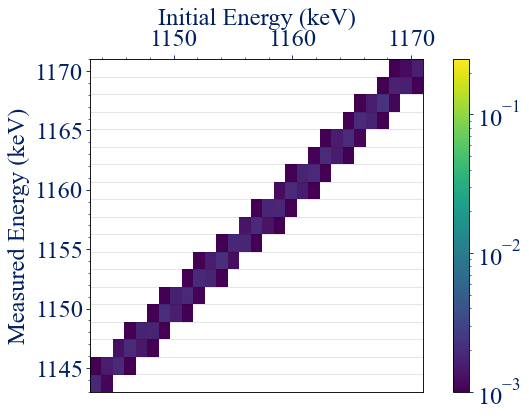

In [253]:
plt.figure()

vmin = 0.001
vmax = 0.25
plt.imshow(Y2-R1, origin='lower',
           norm=LogNorm (vmin=vmin, vmax=vmax),
           aspect=1,
           extent=extent
           )
plt.xlabel('Initial Energy (keV)')
plt.ylabel('Measured Energy (keV)')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position('top') 
plt.minorticks_on()
plt.plot([Ei.min(), Ei.max()], [Em.min(), Em.max()], c='r', ls='--', lw=1, alpha=0.2)

for E in np.linspace(mu-window, mu+window, nbins_Em+1):
    plt.axhline(E, lw=1, c='k', alpha=0.1)

plt.colorbar()
plt.show()

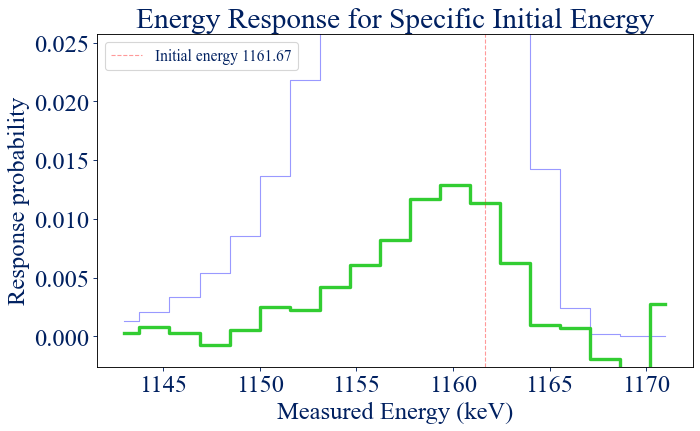

In [15]:
i = nbins_Ei * 2 // 3 # np.random.randint(nbins_Ei)

plt.title('Energy Response for Specific Initial Energy')
plt.step(Em, R[:, i], where='mid', lw=1, alpha=0.4)
plt.step(Em, R1[:, i], where='mid', c='limegreen')
plt.axvline(Ei[i], c='r', ls='--', lw=1, alpha=0.4,
            label=f'Initial energy {Ei[i]:.2f}')
plt.xlabel('Measured Energy (keV)')
plt.ylabel('Response probability')
plt.ylim([-R1[:, i].max() / 5, R1[:, i].max() * 2])
plt.legend(fontsize=14)
plt.show()

In [16]:
with np.printoptions(threshold=20):
    print(np.sum(R, axis=1))

[8.30017774 9.40877412 9.83963488 9.93807519 9.94598827 9.93698212
 9.92083167 9.89499312 9.85378695 9.78807667 9.68329049 9.51619115
 9.24972462 8.82486549 8.14882519 7.08912759 5.53056095 3.58469993
 1.7599678 ]


In [17]:
np.sum(R1, axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1.])

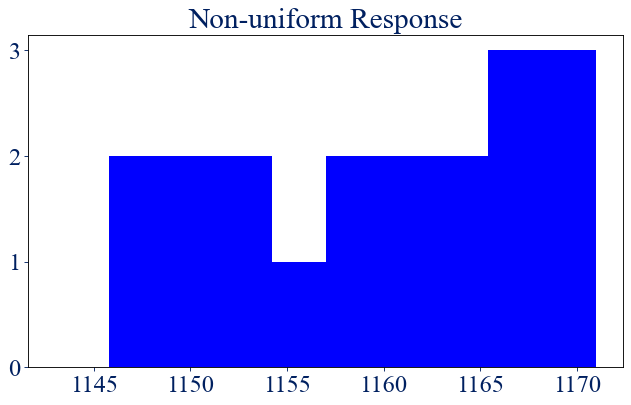

In [18]:
plt.title('Non-uniform Response')       # Ideal would be a flat histogram. 
plt.hist(np.dot(R1, Ei), bins=np.linspace(mu-window, mu+window, 11))
plt.show()

In [20]:
idx = 8

MAXITER = 200
M = np.ones(Ei.shape)
d = np.zeros(Em.shape)
d[idx] = 50
for i in range(MAXITER):
    E = np.dot(R1, M)
    C = np.dot(R1.T, d/E)
    M = C * M

Ei[np.argmax(M)], Em[idx]

(1156.9498207885304, 1155.4444444444443)

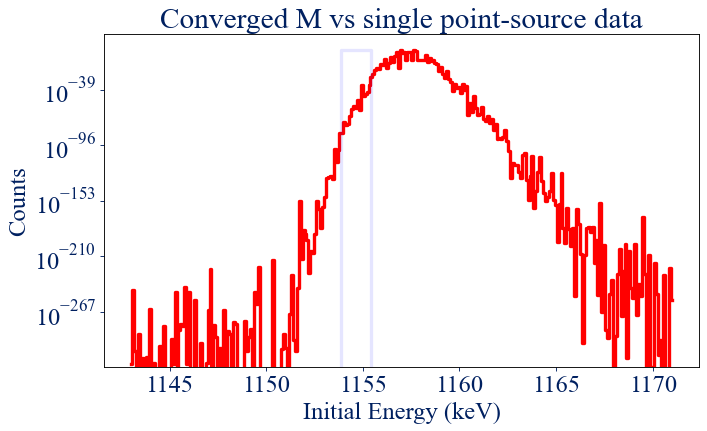

In [21]:
plt.title('Converged M vs single point-source data')
plt.step(Ei, M, where='mid', c='r')
plt.step(Em, d, alpha=0.1, lw=3)
plt.xlabel('Initial Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.show()

In [23]:
nbins_res = 100000
numphotons = 10000          # To investigate high-resolution response, ensure numphotons ~< nbins_res

population = np.linspace(mu - window, mu + window, nbins_res)      # This mu +/- window is only used to define the window of interest. Does not affect weights calculation
weights = expgaussianleft(population, center=Em[idx], sigma=2, gamma=0.3)
# weights = gaussian(population, center=Em[idx], sigma=2)
data = choices(population, weights, k=numphotons)

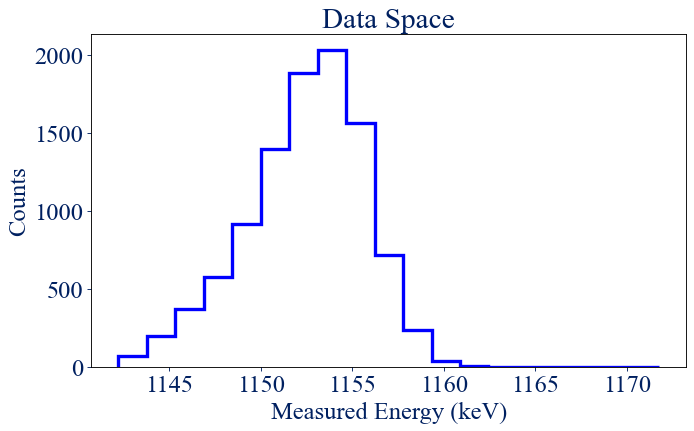

In [24]:
counts, bins, _ = plt.hist(data, np.linspace(mu - window - binwidth_Em/2, mu + window + binwidth_Em/2, nbins_Em+1), histtype='step', lw=3)      # Expanding the window by binwidth_Em to ensure that bincenters is equivalent to Em. Some numerical small-ness issues may arise
bincenters = (bins[:-1] + bins[1:]) / 2
plt.title('Data Space')
plt.xlabel('Measured Energy (keV)')
plt.ylabel('Counts')
plt.show()

In [25]:
# RL Implementation
MAXITER = 1000
d = counts
M = np.ones(Ei.shape)
for i in range(MAXITER):
    E = np.dot(R1, M)
    C = np.dot(R1.T, d/E) #/ np.sum(R1, axis=0)      # TODO: Understand how this normalization affects initial energy counts and response-convolved initial energy counts
    M = C * M

Ei[np.argmax(M)], Em[idx]       # TODO: Calculate this error analytically and compare

(1154.5412186379929, 1155.4444444444443)

In [26]:
np.sum(counts), np.sum(M)       # Sanity check

(10000.0, 10000.0)

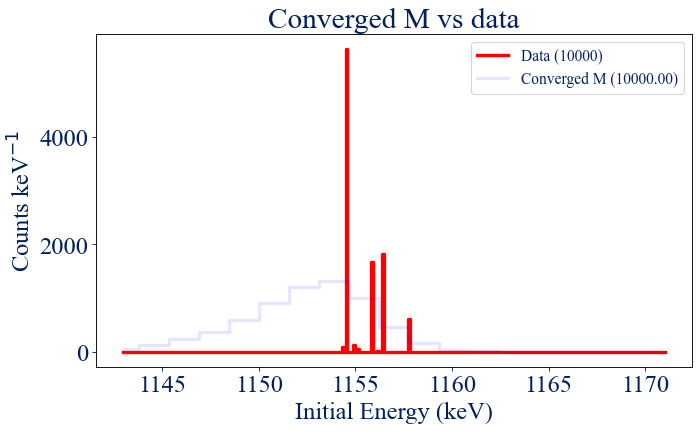

In [34]:
plt.title('Converged M vs data')
plt.step(Ei, np.round(M), where='mid', c='r', label=f'Data ({np.sum(counts):.0f})')       # Normalized with binwidth to compare histograms with different binning
# plt.step(Ei, np.round(M) / binwidth_Ei, where='mid', c='r', label=f'Data ({np.sum(counts):.0f})')       # Normalized with binwidth to compare histograms with different binning
plt.step(bincenters, counts / binwidth_Em, where='mid', alpha=0.1, lw=3, label=f'Converged M ({np.sum(M):.2f})')
plt.xlabel('Initial Energy (keV)')
plt.ylabel('Counts keV$^{-1}$')
plt.legend(fontsize=14)
# plt.yscale('log')
plt.show()

In [28]:
len(np.dot(R1, M)), len(counts)

(19, 19)

In [29]:
np.sum(np.dot(R1, M)/np.dot(R1, M).max()), np.sum(counts/counts.max())

(5.099914325000077, 4.914004914004915)

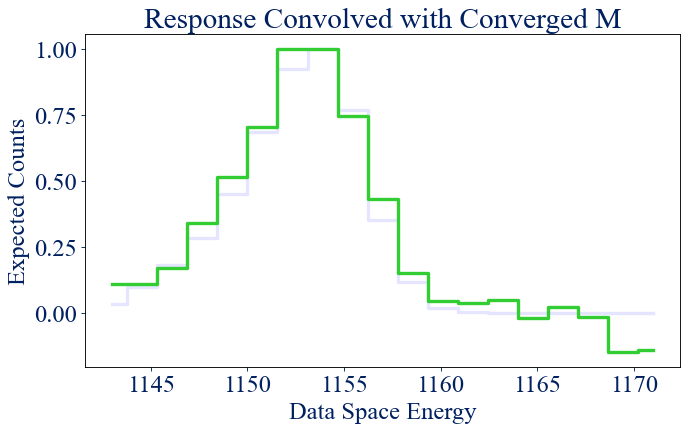

In [31]:
plt.title('Response Convolved with Converged M')
# plt.step(bincenters, counts, where='mid', alpha=0.1, lw=3, label=f'Converged M ({np.sum(M):.2f})')
# plt.step(Em, np.dot(R1, M), where='mid', c='limegreen')     # TODO: Why is this not scaled correctly, even though the sigma and center are aligned
plt.step(bincenters, counts/counts.max(), where='mid', alpha=0.1, lw=3, label=f'Converged M ({np.sum(M):.2f})')
plt.step(Em, np.dot(R1, M)/np.dot(R1, M).max(), where='mid', c='limegreen')
plt.ylabel('Expected Counts')
plt.xlabel('Data Space Energy')
plt.show()

### Unbinned Analysis Attempt

In [35]:
nbins_res = 100000
numphotons = 500          # To investigate high-resolution response, ensure numphotons ~< nbins_res

population = np.linspace(mu - window, mu + window, nbins_res)      # This mu +/- window is only used to define the window of interest. Does not affect weights calculation
# weights = expgaussianleft(population, center=Em[idx], sigma=2, gamma=0.3)
weights = gaussian(population, center=Em[idx], sigma=2)
data = choices(population, weights, k=numphotons)

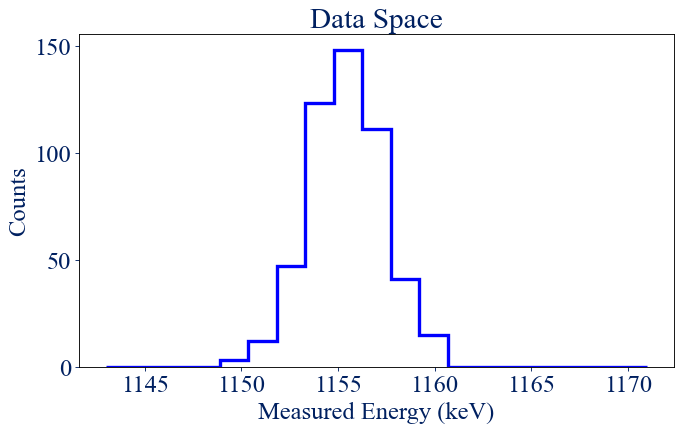

In [36]:
counts, bins, _ = plt.hist(data, np.linspace(mu - window, mu + window, nbins_Em+1), histtype='step', lw=3)
plt.title('Data Space')
plt.xlabel('Measured Energy (keV)')
plt.ylabel('Counts')
plt.show()

In [37]:
MAXITER = 1000
d = counts
M = np.ones(Ei.shape)
for i in range(MAXITER):
    E = np.dot(R1, M)
    C = np.dot(R1.T, d/E)
    M = C * M

Ei[np.argmax(M)], Em[idx]

(1157.752688172043, 1155.4444444444443)

In [38]:
np.sum(counts), np.sum(M)

(500.0, 500.00000000000006)

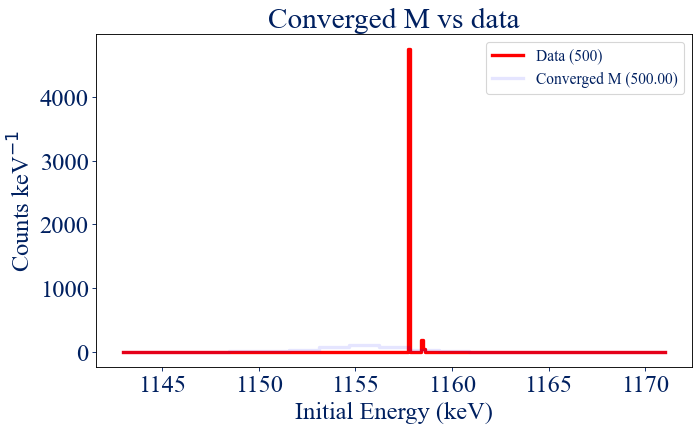

In [39]:
plt.title('Converged M vs data')
plt.step(Ei, np.round(M) / binwidth_Ei, where='mid', c='r', label=f'Data ({np.sum(counts):.0f})')       # Normalized with binwidth to compare histograms with different binning
plt.step(bincenters, counts / binwidth_Em, where='mid', alpha=0.1, lw=3, label=f'Converged M ({np.sum(M):.2f})')
plt.xlabel('Initial Energy (keV)')
plt.ylabel('Counts keV$^{-1}$')
plt.legend(fontsize=14)
# plt.yscale('log')
plt.show()

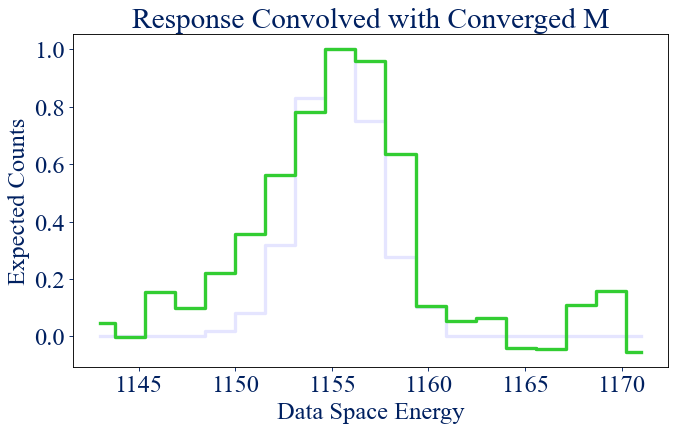

In [40]:
plt.title('Response Convolved with Converged M')
plt.step(bincenters, counts/counts.max(), where='mid', alpha=0.1, lw=3, label=f'Converged M ({np.sum(M):.2f})')
plt.step(Em, np.dot(R1, M)/np.dot(R1, M).max(), where='mid', c='limegreen')
plt.ylabel('Expected Counts')
plt.xlabel('Data Space Energy')
plt.show()

In [41]:
Em.shape, R1.shape

((19,), (19, 280))

In [42]:
def get_response(Emprime):                  # Input: measured photon energy
    idx = np.where(Em < Emprime)[0][-1]     # Nearest rounded down bincenter. NOTE: Can define more complicated functions
    offset = Emprime - Em[idx]
    return (R1[idx, :] * (binwidth_Em - offset) + R1[idx+1, :] * offset) / binwidth_Em, idx       # Linear interpolation along Em axis only

Emprime = 1154.50                       # Measured photon energy
get_response(Emprime)

(array([ 2.77050574e-04, -1.13828093e-03,  2.89808238e-04,  8.10130761e-05,
        -4.95524741e-04, -7.88163874e-05,  4.44195387e-04,  8.03477204e-05,
         8.57989206e-04,  1.79251211e-04, -1.55130537e-04,  1.76392399e-04,
        -4.74840335e-04,  3.88735496e-04, -5.61470391e-04,  5.23389844e-04,
         1.64013067e-04, -5.31986154e-04, -1.25043698e-05, -5.30787732e-04,
        -4.38928752e-04,  5.25202127e-04,  4.96772291e-04,  1.33231558e-04,
        -5.60207363e-04,  4.15654221e-04,  7.78217188e-04, -2.12151680e-04,
         8.12216223e-04,  2.84459446e-05, -3.55460608e-04, -3.24839073e-04,
        -7.11888619e-06, -5.83845864e-04, -2.57769931e-04,  1.20741803e-04,
        -3.82147192e-04,  3.04865010e-05, -2.10607291e-04, -1.71472088e-06,
         3.65754147e-05, -1.40562707e-04,  2.70604668e-04, -7.80866590e-05,
        -6.25784621e-05,  7.03785871e-04,  1.00680880e-04, -2.37898023e-04,
        -6.02181692e-04,  2.96010937e-04,  7.54445836e-05, -6.00447157e-05,
         5.6

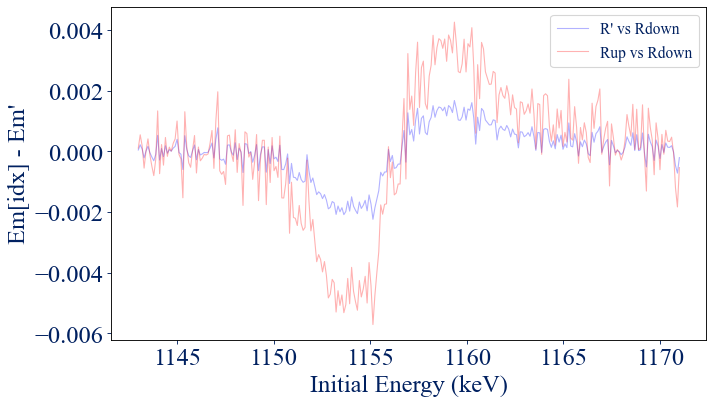

In [43]:
Rprime, index = get_response(Emprime)
plt.plot(Ei, Rprime - R1[index, :], lw=1, alpha=0.3, label="R' vs Rdown")
plt.plot(Ei, R1[index+1, :] - R1[index, :], lw=1, alpha=0.3, label="Rup vs Rdown")
# plt.plot(Ei, R1[index+1, :] - Rprime, lw=1, alpha=0.3, label="Rup vs R'")
plt.ylabel("Em[idx] - Em'")
plt.xlabel('Initial Energy (keV)')
plt.legend(fontsize=14)
plt.show()

### Projecting Response File

In [1]:
import h5py

In [2]:
path_data = "/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/tutorials/data/"
response_path = path_data + "psr_gal_Ti44_E_1143_1171keV_DC2.h5"

In [3]:
f = h5py.File(response_path, 'r')

In [99]:
f['hist/contents'][np.random.randint(3072), :, :, 30, 1536]

array([[   0.        ,    0.        ,    0.        ],
       [   0.        , 4942.15904647,    0.        ],
       [   0.        ,    0.        ,    0.        ]])

In [4]:
f['hist/contents'][..., 1536]

array([[[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]],


       [[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.

In [16]:
f['hist/axes']['1'][:]

array([1150., 1164.])

In [ ]:
from histpy import Histogram
image_response = Histogram.open(response_path)